## Step 0: Install dependencies
Run this once. If already installed, you can skip it.

In [1]:
!pip install -q -U langchain langchain-aws langgraph boto3 botocore matplotlib pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.7/163.7 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.2/250.2 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 6.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour i

## Step 1: AWS Bedrock credentials


In [ ]:
import os

os.environ["AWS_BEARER_TOKEN_BEDROCK"] = "PASTE_YOUR_KEY_HERE"
os.environ["AWS_REGION"] = "ap-southeast-2"

if os.environ["AWS_BEARER_TOKEN_BEDROCK"] == "PASTE_YOUR_KEY_HERE":
    print("⚠️  You still need to paste your actual Bedrock API key above!")
else:
    print("Bedrock API key set. Region:", os.environ.get("AWS_REGION"))

## Step 2: Set up the Bedrock LLM

In [6]:
from langchain_aws import ChatBedrockConverse
from langchain_core.messages import HumanMessage

llm = ChatBedrockConverse(
    model_id="global.amazon.nova-2-lite-v1:0",
    region_name=os.environ.get("AWS_REGION", "ap-southeast-2"),
    temperature=0.7,
    max_tokens=512,
)

# Quick sanity check
test = llm.invoke([HumanMessage(content="Say: Bedrock agent ready!")])
print("✅ LLM initialized successfully!")
print("   Model  :", "global.amazon.nova-2-lite-v1:0")
print("   Region :", os.environ.get("AWS_REGION", "ap-southeast-2"))
print("   Test   :", test.content[:60])

✅ LLM initialized successfully!
   Model  : global.amazon.nova-2-lite-v1:0
   Region : ap-southeast-2
   Test   : ### Bedrock Agent Ready!

✅ **Status:** Active and Operation


## Step 3: Define the 5 tools
Each tool uses the `@tool` decorator with a clear docstring so the LLM knows when to call it.

In [7]:
from langchain_core.tools import tool
from datetime import date

expense_log = []

# Hardcoded monthly budget limits (PKR)
BUDGET_LIMITS = {
    "food": 15000,
    "transport": 8000,
    "entertainment": 5000,
    "shopping": 10000,
}

# Hardcoded exchange rates (base unit = 1 USD)
EXCHANGE_RATES = {
    "USD": 1.0,
    "PKR": 278.50,
    "EUR": 0.92,
    "GBP": 0.79,
    "AED": 3.67,
}

# Hardcoded money-saving tips per category
SPENDING_TIPS = {
    "food": "Try meal-prepping on weekends and limit eating out to once a week — it can cut food spend by 20-30%.",
    "transport": "Consider carpooling or public transport for routine commutes to reduce fuel/ride-hailing costs.",
    "entertainment": "Look for free or discounted events, and set a fixed weekly entertainment allowance.",
    "shopping": "Use a 24-hour rule before non-essential purchases to avoid impulse buying.",
}


@tool
def calculate_expense(amount: float, category: str, description: str) -> str:
    """Log an expense with amount, category and description."""
    category = category.lower().strip()
    entry = {
        "amount": amount,
        "category": category,
        "description": description,
        "date": str(date.today()),
    }
    expense_log.append(entry)
    return (
        f"Expense logged: {amount} PKR under '{category}' "
        f"({description}) on {entry['date']}."
    )


@tool
def get_budget_status(category: str) -> str:
    """Check remaining budget for a category (food / transport / entertainment / shopping)."""
    category = category.lower().strip()
    if category not in BUDGET_LIMITS:
        return f"Unknown category '{category}'. Valid categories: {list(BUDGET_LIMITS.keys())}."

    limit = BUDGET_LIMITS[category]
    spent = sum(e["amount"] for e in expense_log if e["category"] == category)
    remaining = limit - spent

    return (
        f"Category: {category}. Monthly limit: {limit} PKR. "
        f"Spent so far: {spent} PKR. Remaining budget: {remaining} PKR."
    )


@tool
def convert_currency(amount: float, from_currency: str, to_currency: str) -> str:
    """Convert between currencies using fixed rates."""
    from_currency = from_currency.upper().strip()
    to_currency = to_currency.upper().strip()

    if from_currency not in EXCHANGE_RATES or to_currency not in EXCHANGE_RATES:
        return f"Unsupported currency. Supported: {list(EXCHANGE_RATES.keys())}."

    amount_in_usd = amount / EXCHANGE_RATES[from_currency]
    converted = amount_in_usd * EXCHANGE_RATES[to_currency]

    return f"{amount} {from_currency} = {round(converted, 2)} {to_currency}."


@tool
def calculate_savings_goal(target_amount: float, monthly_savings: float) -> str:
    """Calculate how long to reach a savings target."""
    if monthly_savings <= 0:
        return "Monthly savings must be greater than 0 to calculate a timeline."

    months_needed = target_amount / monthly_savings
    months_rounded = int(months_needed) + (1 if months_needed % 1 > 0 else 0)

    return (
        f"To save {target_amount} PKR at {monthly_savings} PKR/month, "
        f"you will need {months_rounded} month(s)."
    )


@tool
def get_spending_tip(category: str) -> str:
    """Return a money-saving tip for a spending category."""
    category = category.lower().strip()
    tip = SPENDING_TIPS.get(category)
    if not tip:
        return f"No tip available for '{category}'. Try: {list(SPENDING_TIPS.keys())}."
    return f"Tip for {category}: {tip}"


print("✅ All 5 tools defined:", "calculate_expense, get_budget_status, convert_currency, calculate_savings_goal, get_spending_tip")

✅ All 5 tools defined: calculate_expense, get_budget_status, convert_currency, calculate_savings_goal, get_spending_tip


In [8]:
tools = [
    calculate_expense,
    get_budget_status,
    convert_currency,
    calculate_savings_goal,
    get_spending_tip,
]
try:
    from langchain.agents import create_agent
except ImportError:
    from langgraph.prebuilt import create_react_agent as create_agent

agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt="You are a helpful personal finance assistant.",
)


def run_agent(query: str) -> str:
    result = agent.invoke({"messages": [{"role": "user", "content": query}]})
    return result["messages"][-1].content


print("Agent ready with tools:", [t.name for t in tools])

Agent ready with tools: ['calculate_expense', 'get_budget_status', 'convert_currency', 'calculate_savings_goal', 'get_spending_tip']


In [9]:
# Query 1 — expects Tool 3 (convert_currency) + Tool 1 (calculate_expense)
print(run_agent("I spent 50 USD on food today, convert it to PKR and log it"))

Great! I've converted your $50 USD food expense to 13,925 PKR and logged it successfully under the 'food' category. Your expense has been recorded with the description "Food purchase" for today, September 25, 2026.


In [10]:
# Query 2 — expects Tool 2 (get_budget_status)
print(run_agent("What is my remaining budget for entertainment?"))

Your remaining budget for entertainment is **5,000 PKR**. You haven't spent anything in this category yet this month.


In [11]:
# Query 3 — expects Tool 4 (calculate_savings_goal)
print(run_agent("I want to save 100,000 PKR. I can save 10,000 per month. When will I reach my goal?"))

You will reach your savings goal of 100,000 PKR in **10 months** if you save 10,000 PKR each month.


In [12]:
# Query 4 — expects Tool 5 (get_spending_tip)
print(run_agent("I keep overspending on food, give me a money-saving tip"))

Here's a tip to help you save on food expenses: **Try meal-prepping on weekends and limit eating out to once a week** — this simple change can cut your food spending by 20-30%. 

Meal prepping lets you buy ingredients in bulk and cook larger batches, which is usually cheaper than buying pre-prepared meals or dining out. Planning your meals for the week also helps you avoid impulse buys and reduces food waste.


In [13]:
# Query 5 — expects Tool 1 (calculate_expense) + Tool 2 (get_budget_status)
print(run_agent("Log 2000 PKR for transport and show my transport budget status"))

I've logged your transport expense of 2000 PKR and checked your budget status.

Your transport budget details:
- Monthly limit: 8000 PKR
- Spent so far: 2000 PKR
- Remaining budget: 6000 PKR

You're currently within your budget for transportation this month!


## Step 6: Your own compound query

In [14]:
# Custom compound query — expects Tool 1 (calculate_expense) + Tool 5 (get_spending_tip)
print(run_agent(
    "I just spent 3000 PKR on shopping, log it and also give me a tip so I stop overspending on shopping"
))

Your shopping expense of 3,000 PKR has been logged successfully!

Here's a tip to help you avoid overspending on shopping: **Use a 24-hour rule before non-essential purchases to avoid impulse buying.** This means if you're tempted to buy something that's not absolutely necessary, wait 24 hours before purchasing it. This pause can help you decide if it's truly something you need or just a want, helping you make more mindful spending decisions.


## Step 7: Inspect the logged expenses

In [15]:
import pandas as pd

expenses_df = pd.DataFrame(expense_log)
expenses_df

,amount,category,description,date
0,13925.0,food,Food purchase,2026-09-25
1,2000.0,transport,Transport expense,2026-09-25
2,3000.0,shopping,shopping expenses,2026-09-25


## Step 8: 📊 Visual Dashboard


/tmp/ipykernel_3570/1520932794.py:116: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.savefig("dashboard.png", dpi=160, facecolor=COLOR_BG, bbox_inches="tight")
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


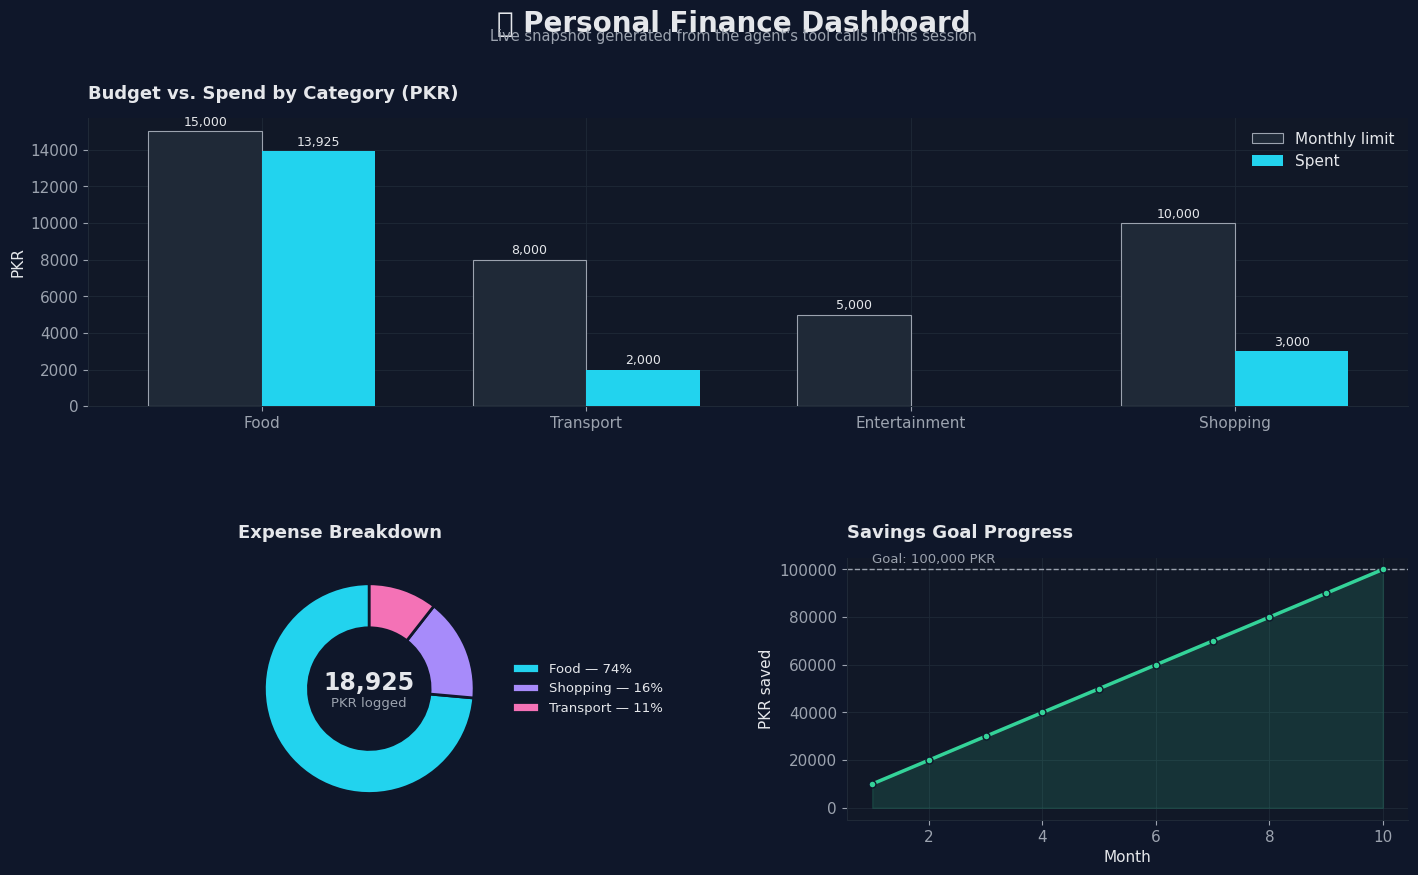


✅ Dashboard saved as dashboard.png — great for your submission screenshots!


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ---- Brand-neutral, accessible palette ----
COLOR_BG = "#0f172a"
COLOR_PANEL = "#111827"
COLOR_TEXT = "#e5e7eb"
COLOR_MUTED = "#9ca3af"
COLOR_GRID = "#1f2937"
COLOR_ACCENT = "#22d3ee"     # cyan — spent
COLOR_ACCENT2 = "#34d399"    # green — remaining / under budget
COLOR_WARN = "#f87171"       # red — over budget
PIE_COLORS = ["#22d3ee", "#a78bfa", "#f472b6", "#fbbf24", "#34d399", "#60a5fa"]

plt.rcParams.update({
    "figure.facecolor": COLOR_BG,
    "axes.facecolor": COLOR_PANEL,
    "axes.edgecolor": COLOR_GRID,
    "axes.labelcolor": COLOR_TEXT,
    "text.color": COLOR_TEXT,
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "font.size": 11,
    "font.family": "DejaVu Sans",
    "axes.grid": True,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.6,
})

# Rebuild the dataframe fresh (in case new expenses were logged after Step 7)
df = pd.DataFrame(expense_log)

fig = plt.figure(figsize=(15, 9))
fig.suptitle("💰 Personal Finance Dashboard", fontsize=20, fontweight="bold", color=COLOR_TEXT, y=0.98)
fig.text(0.5, 0.945, "Live snapshot generated from the agent's tool calls in this session",
          ha="center", fontsize=10.5, color=COLOR_MUTED)

gs = fig.add_gridspec(2, 2, height_ratios=[1.1, 1], hspace=0.55, wspace=0.35,
                       left=0.07, right=0.95, top=0.86, bottom=0.08)

# ---------- Chart 1: Budget vs Spent (grouped bar) ----------
ax1 = fig.add_subplot(gs[0, :])
categories = list(BUDGET_LIMITS.keys())
spent_by_cat = [
    df[df["category"] == c]["amount"].sum() if not df.empty and c in df["category"].values else 0
    for c in categories
]
limits = [BUDGET_LIMITS[c] for c in categories]
x = np.arange(len(categories))
width = 0.35

bars_limit = ax1.bar(x - width/2, limits, width, label="Monthly limit",
                      color=COLOR_GRID, edgecolor=COLOR_MUTED, linewidth=0.8, zorder=3)
bar_colors = [COLOR_WARN if s > l else COLOR_ACCENT for s, l in zip(spent_by_cat, limits)]
bars_spent = ax1.bar(x + width/2, spent_by_cat, width, label="Spent",
                      color=bar_colors, edgecolor="none", zorder=3)

for rect in list(bars_limit) + list(bars_spent):
    h = rect.get_height()
    if h > 0:
        ax1.annotate(f"{int(h):,}", (rect.get_x() + rect.get_width()/2, h),
                      textcoords="offset points", xytext=(0, 4), ha="center",
                      fontsize=9, color=COLOR_TEXT)

ax1.set_title("Budget vs. Spend by Category (PKR)", fontsize=13, fontweight="bold", pad=14, loc="left")
ax1.set_xticks(x)
ax1.set_xticklabels([c.title() for c in categories])
ax1.set_ylabel("PKR")
ax1.legend(frameon=False, loc="upper right", labelcolor=COLOR_TEXT)
ax1.spines[["top", "right"]].set_visible(False)
ax1.set_axisbelow(True)

# ---------- Chart 2: Expense breakdown (donut) ----------
ax2 = fig.add_subplot(gs[1, 0])
if not df.empty:
    by_cat = df.groupby("category")["amount"].sum()
    wedges, _ = ax2.pie(
        by_cat.values, colors=PIE_COLORS[:len(by_cat)], startangle=90,
        wedgeprops=dict(width=0.42, edgecolor=COLOR_BG, linewidth=2),
    )
    total = by_cat.sum()
    ax2.text(0, 0.06, f"{total:,.0f}", ha="center", va="center", fontsize=17,
              fontweight="bold", color=COLOR_TEXT)
    ax2.text(0, -0.14, "PKR logged", ha="center", va="center", fontsize=9.5, color=COLOR_MUTED)
    legend_labels = [f"{c.title()} — {v/total:.0%}" for c, v in by_cat.items()]
    ax2.legend(wedges, legend_labels, loc="center left", bbox_to_anchor=(1.0, 0.5),
               frameon=False, labelcolor=COLOR_TEXT, fontsize=9.5)
else:
    ax2.text(0.5, 0.5, "No expenses logged yet\n(run Steps 5 & 6 first)", ha="center", va="center",
              color=COLOR_MUTED, fontsize=10)
    ax2.axis("off")
ax2.set_title("Expense Breakdown", fontsize=13, fontweight="bold", pad=14, loc="left")

# ---------- Chart 3: Savings goal progress ----------
ax3 = fig.add_subplot(gs[1, 1])
target_amount = 100000
monthly_savings = 10000
months_needed = int(np.ceil(target_amount / monthly_savings))
months = np.arange(1, months_needed + 1)
cumulative = np.minimum(months * monthly_savings, target_amount)

ax3.plot(months, cumulative, color=COLOR_ACCENT2, linewidth=2.5, marker="o",
          markersize=5, markerfacecolor=COLOR_ACCENT2, markeredgecolor=COLOR_BG, zorder=3)
ax3.fill_between(months, cumulative, color=COLOR_ACCENT2, alpha=0.15, zorder=2)
ax3.axhline(target_amount, color=COLOR_MUTED, linestyle="--", linewidth=1, zorder=1)
ax3.text(months[0], target_amount * 1.03, f"Goal: {target_amount:,} PKR",
          fontsize=9.5, color=COLOR_MUTED)

ax3.set_title("Savings Goal Progress", fontsize=13, fontweight="bold", pad=14, loc="left")
ax3.set_xlabel("Month")
ax3.set_ylabel("PKR saved")
ax3.spines[["top", "right"]].set_visible(False)
ax3.set_axisbelow(True)

plt.savefig("dashboard.png", dpi=160, facecolor=COLOR_BG, bbox_inches="tight")
plt.show()
print("\n✅ Dashboard saved as dashboard.png — great for your submission screenshots!")